In [1]:
# Load the cleaned Telco Customer Churn dataset

import pandas as pd
import numpy as np

df = pd.read_csv("telco_customer_churn_cleaned.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Separate features and target variable

X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


In [3]:
# Split the data into training, validation, and testing sets

from sklearn.model_selection import train_test_split

# First split: 80% training/validation and 20% testing
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: 80% training and 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.20,
    random_state=42,
    stratify=y_train_val
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Testing set:", X_test.shape)

Training set: (4507, 19)
Validation set: (1127, 19)
Testing set: (1409, 19)


In [5]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [6]:
# Encode the target variable for the neural network

y_train = y_train.map({'No': 0, 'Yes': 1})
y_val = y_val.map({'No': 0, 'Yes': 1})
y_test = y_test.map({'No': 0, 'Yes': 1})

print("Training target values:")
print(y_train.value_counts())

print("\nValidation target values:")
print(y_val.value_counts())

print("\nTesting target values:")
print(y_test.value_counts())

Training target values:
Churn
0    3311
1    1196
Name: count, dtype: int64

Validation target values:
Churn
0    828
1    299
Name: count, dtype: int64

Testing target values:
Churn
0    1035
1     374
Name: count, dtype: int64


In [7]:
# Preprocess input features for the neural network

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# Fit preprocessing only on the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform validation and test data using the same fitted preprocessor
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (4507, 45)
Processed validation shape: (1127, 45)
Processed testing shape: (1409, 45)


In [9]:
# Feature engineering: Average Monthly Spend

def add_engineered_feature(data):
    data = data.copy()

    data['AverageMonthlySpend'] = np.where(
        data['tenure'] > 0,
        data['TotalCharges'] / data['tenure'],
        0
    )

    return data


# Add the engineered feature to all datasets
X_train = add_engineered_feature(X_train)
X_val = add_engineered_feature(X_val)
X_test = add_engineered_feature(X_test)

# Update numerical features
numerical_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Engineered feature added successfully.")
print("New numerical features:")
print(numerical_features)

Engineered feature added successfully.
New numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AverageMonthlySpend']


In [10]:
# Rebuild preprocessing after feature engineering

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), categorical_features)
    ]
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform validation and test data
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (4507, 46)
Processed validation shape: (1127, 46)
Processed testing shape: (1409, 46)


In [11]:
# Verify the processed data before neural network training

print("NaN values in training data:", np.isnan(X_train_processed).sum())
print("Infinite values in training data:", np.isinf(X_train_processed).sum())

print("\nProcessed data type:", X_train_processed.dtype)
print("Number of input features:", X_train_processed.shape[1])

NaN values in training data: 0
Infinite values in training data: 0

Processed data type: float64
Number of input features: 46


In [12]:
# Analyze the target class distribution

print("Training class distribution:")
print(y_train.value_counts())

print("\nTraining class percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

Training class distribution:
Churn
0    3311
1    1196
Name: count, dtype: int64

Training class percentages:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [13]:
# Import TensorFlow and Keras

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("Keras is ready for neural network development.")

TensorFlow version: 2.20.0
Keras is ready for neural network development.


In [14]:
# Build the neural network architecture

model = keras.Sequential([
    layers.Input(shape=(X_train_processed.shape[1],)),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.30),

    layers.Dense(16, activation='relu'),
    layers.Dropout(0.20),

    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,049 (8.00 KB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Compile the neural network

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

print("Neural network compiled successfully.")

Neural network compiled successfully.


In [16]:
# Train the neural network

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate class weights to handle class imbalance
classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, class_weights_array))

print("Class weights:", class_weights)

# Stop training when validation loss stops improving
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

print("\nNeural network training completed.")

Class weights: {np.int64(0): np.float64(0.6806100875868317), np.int64(1): np.float64(1.8841973244147157)}
Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.6301 - auc: 0.7384 - loss: 0.6029 - precision: 0.3971 - recall: 0.7600 - val_accuracy: 0.7728 - val_auc: 0.8256 - val_loss: 0.4927 - val_precision: 0.5526 - val_recall: 0.7559
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7360 - auc: 0.8078 - loss: 0.5367 - precision: 0.5017 - recall: 0.7600 - val_accuracy: 0.7746 - val_auc: 0.8359 - val_loss: 0.4697 - val_precision: 0.5584 - val_recall: 0.7191
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7264 - auc: 0.8136 - loss: 0.5259 - precision: 0.4902 - recall: 0.7742 - val_accuracy: 0.7702 - val_auc: 0.8387 - val_loss: 0.4669 - val_precision: 0.5474 - val_recall: 0.7726
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7428 - auc: 0.8246 - loss: 0.5167 - precision: 0.5101 - recall: 0.7809 - val_accuracy: 0.7640 - va

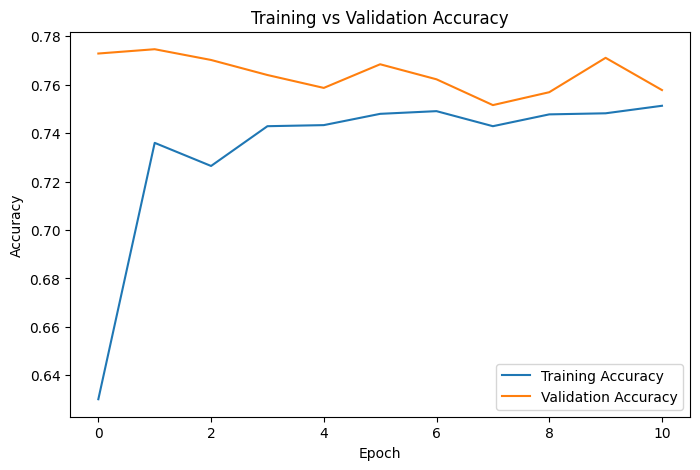

In [18]:
# Visualize training and validation performance

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

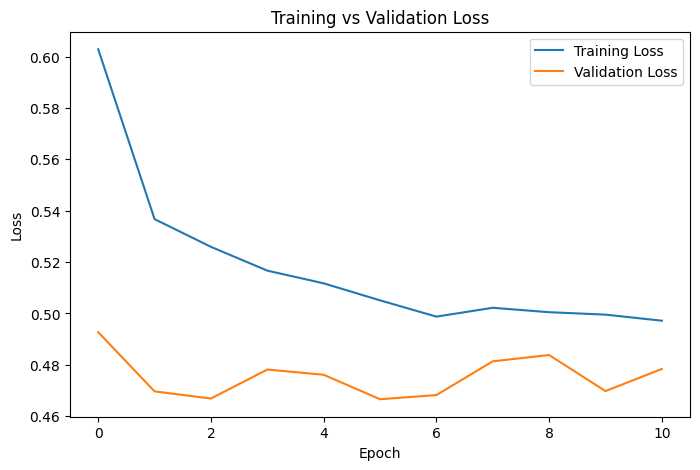

In [19]:
# Visualize training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [20]:
# Evaluate the neural network on the unseen test dataset

test_results = model.evaluate(
    X_test_processed,
    y_test,
    verbose=0
)

print("Test Loss     :", round(test_results[0], 4))
print("Test Accuracy :", round(test_results[1], 4))
print("Test Precision:", round(test_results[2], 4))
print("Test Recall   :", round(test_results[3], 4))
print("Test ROC-AUC   :", round(test_results[4], 4))

Test Loss     : 0.4746
Test Accuracy : 0.7516
Test Precision: 0.5222
Test Recall   : 0.754
Test ROC-AUC   : 0.8394


In [21]:
# Generate predictions on the test dataset

y_test_proba = model.predict(
    X_test_processed,
    verbose=0
).ravel()

# Convert probabilities into binary predictions
y_test_pred = (y_test_proba >= 0.5).astype(int)

print("Number of test predictions:", len(y_test_pred))
print("First 10 predicted probabilities:")
print(np.round(y_test_proba[:10], 4))

print("\nFirst 10 predicted classes:")
print(y_test_pred[:10])

Number of test predictions: 1409
First 10 predicted probabilities:
[0.119  0.8694 0.198  0.489  0.0993 0.752  0.6156 0.2761 0.0179 0.5946]

First 10 predicted classes:
[0 1 0 0 0 1 1 0 0 1]


Confusion Matrix:
[[777 258]
 [ 92 282]]


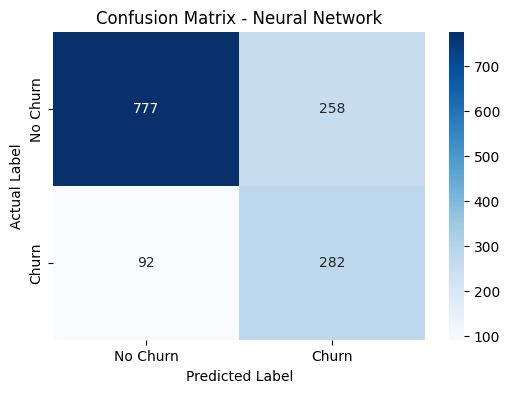

In [22]:
# Create and visualize the confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Neural Network')
plt.show()

In [23]:
# Generate the classification report

from sklearn.metrics import classification_report

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=['No Churn', 'Churn']
    )
)

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.75      0.82      1035
       Churn       0.52      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409



ROC-AUC: 0.8394


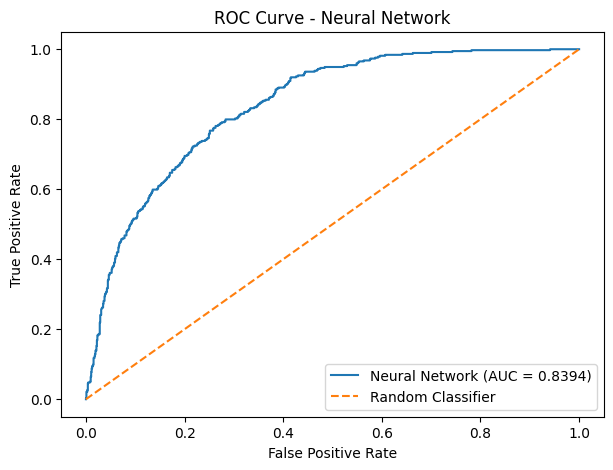

In [24]:
# Plot the ROC curve for the neural network

from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_test_proba
)

# Calculate ROC-AUC
roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

print("ROC-AUC:", round(roc_auc, 4))

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f'Neural Network (AUC = {roc_auc:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Neural Network')
plt.legend()
plt.show()

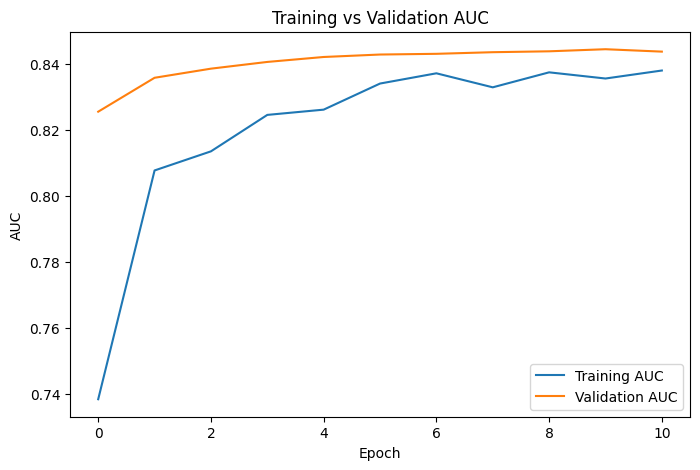

In [25]:
# Visualize training and validation AUC

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['auc'],
    label='Training AUC'
)

plt.plot(
    history.history['val_auc'],
    label='Validation AUC'
)

plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Training vs Validation AUC')
plt.legend()
plt.show()

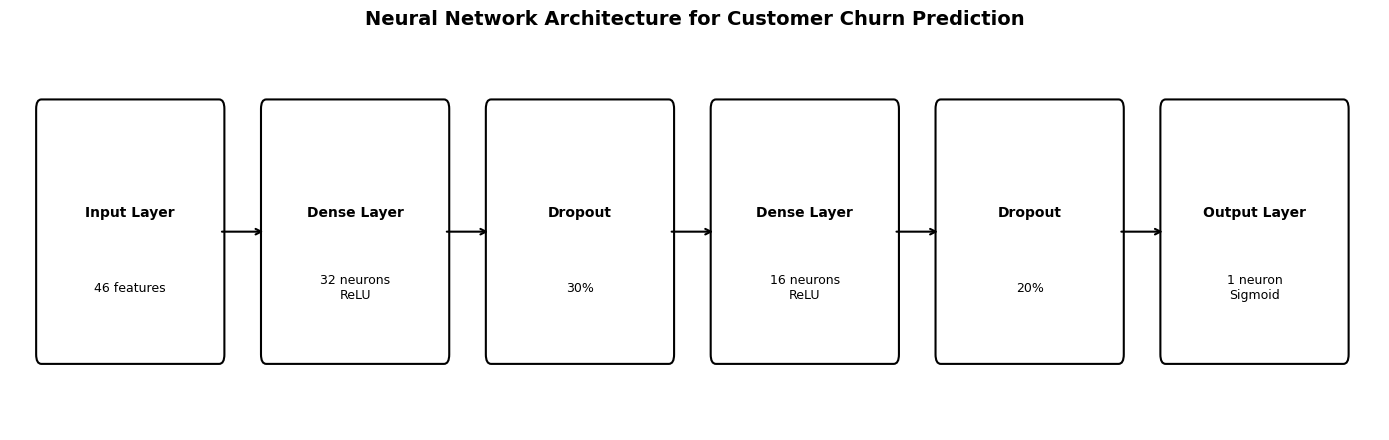

In [27]:
# Create a complete neural network architecture diagram

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 4.5))

layers_info = [
    ("Input Layer", "46 features"),
    ("Dense Layer", "32 neurons\nReLU"),
    ("Dropout", "30%"),
    ("Dense Layer", "16 neurons\nReLU"),
    ("Dropout", "20%"),
    ("Output Layer", "1 neuron\nSigmoid")
]

box_width = 1.7
box_height = 1.3
gap = 0.45

for i, (title, details) in enumerate(layers_info):

    x = i * (box_width + gap)

    box = FancyBboxPatch(
        (x, 0.8),
        box_width,
        box_height,
        boxstyle="round,pad=0.05",
        edgecolor="black",
        facecolor="white",
        linewidth=1.5
    )

    ax.add_patch(box)

    ax.text(
        x + box_width / 2,
        1.55,
        title,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

    ax.text(
        x + box_width / 2,
        1.15,
        details,
        ha="center",
        va="center",
        fontsize=9
    )

    if i < len(layers_info) - 1:

        ax.annotate(
            "",
            xy=(x + box_width + gap, 1.45),
            xytext=(x + box_width, 1.45),
            arrowprops=dict(
                arrowstyle="->",
                lw=1.5
            )
        )

ax.set_xlim(-0.3, 12.8)
ax.set_ylim(0.4, 2.5)
ax.axis("off")

plt.title(
    "Neural Network Architecture for Customer Churn Prediction",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Neural Network Architecture and Design Justification

The neural network was designed as a compact feed-forward neural network suitable for binary customer churn classification.

### Architecture

- **Input Layer:** 46 features
- **Dense Layer:** 32 neurons with ReLU activation
- **Dropout:** 30%
- **Dense Layer:** 16 neurons with ReLU activation
- **Dropout:** 20%
- **Output Layer:** 1 neuron with Sigmoid activation

### Design Decisions

The input layer contains 46 neurons because the preprocessing and feature engineering steps produced 46 numerical input features.

Two hidden Dense layers were selected to allow the network to learn non-linear relationships between customer characteristics and churn. The first layer contains 32 neurons to learn broader patterns, while the second layer contains 16 neurons to progressively reduce the representation before classification.

ReLU activation was used in the hidden layers because it is computationally efficient and suitable for learning non-linear relationships.

Dropout rates of 30% and 20% were introduced to reduce overfitting by randomly disabling a proportion of neurons during training.

The output layer contains one neuron with a Sigmoid activation function because the problem is binary classification. The output represents the estimated probability of customer churn.

### Training Hyperparameters

- **Optimizer:** Adam
- **Learning Rate:** 0.001
- **Loss Function:** Binary Cross-Entropy
- **Maximum Epochs:** 50
- **Batch Size:** 32
- **Early Stopping Patience:** 5
- **Class Weighting:** Balanced class weights

Class weighting was incorporated because the dataset contains fewer churn customers than non-churn customers. Early Stopping was used to prevent unnecessary training when validation loss stopped improving.